# Tesla Deliveries & Production End-to-End ML Pipeline
### Dataset : Tesla EA Deliveries and Production Data (2015-2025)
**Goal :** Predict estimated deliveries using preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning and time series forecasting.

## Step 1 Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

print(" All libraries imported successfully!")

 All libraries imported successfully!


## Step 2 Loading the Dataset

In [3]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(" Shape:", df.shape)
print("\n Columns:", df.columns.tolist())
print("\n First 5 rows:")
display(df.head())

print("\n Dataset Info:")
df.info()

print("\n Statistical Summary:")
display(df.describe())

 Shape: (2640, 12)

 Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

 First 5 rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

 Statistical Summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Step 3 Sorting Data by Time Order

Since this is time series data, the row order matters a lot. The raw data was shuffled 2023 might come before 2015 which makes no sense. So we sort everything by Year and Month first. This is important because later when we create lag features and do the train-test split, the time order must be correct otherwise the features will be meaningless.

In [4]:
df = df.sort_values(by=['Year', 'Month']).reset_index(drop=True)

print(" Data sorted by Year and Month!")
print("\nFirst 10 rows after sorting:")
print(df[['Year', 'Month', 'Estimated_Deliveries']].head(10))

 Data sorted by Year and Month!

First 10 rows after sorting:
   Year  Month  Estimated_Deliveries
0  2015      1                 10348
1  2015      1                 12446
2  2015      1                 10835
3  2015      1                  8122
4  2015      1                 13902
5  2015      1                  7597
6  2015      1                  7419
7  2015      1                  9537
8  2015      1                 11325
9  2015      1                  7292


## Step 4 Checking Missing Values and Duplicates

In [5]:
print(" Missing Values:")
print(df.isnull().sum())

print("\n Duplicate Rows:", df.duplicated().sum())

if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
 print("\n No missing values or duplicates found! Data is clean.")
else:
 df = df.drop_duplicates()
 df = df.dropna()
 print(f"\n Cleaned. New shape: {df.shape}")

 Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

 Duplicate Rows: 0

 No missing values or duplicates found! Data is clean.


## Step 5 EDA (Exploratory Data Analysis)

EDA is basically getting to know your data through graphs and statistics before doing any modeling. Instead of just looking at numbers in a table, we visualize things to spot patterns, trends and problems. This helps us make better decisions about which columns to keep, which to drop and what features to create.

### 5.1 Estimated Deliveries by Model

Here we are checking which Tesla model has the highest average deliveries. This gives us an idea of which models are most popular and contribute most to overall sales.

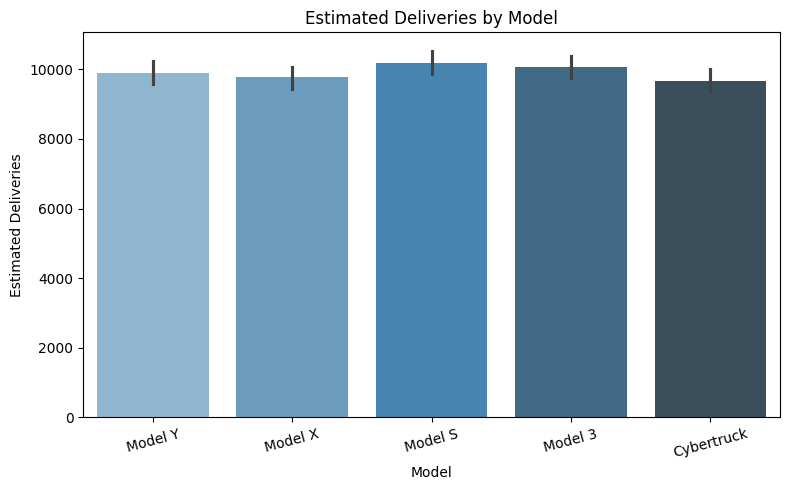

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Model', y='Estimated_Deliveries',
 hue='Model', palette='Blues_d', legend=False)
plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 5.2 Estimated Deliveries by Region

Here we are checking which region buys the most Tesla cars. North America, Europe, Asia or Middle East which one leads? This kind of info is useful for understanding the geographical distribution of sales.

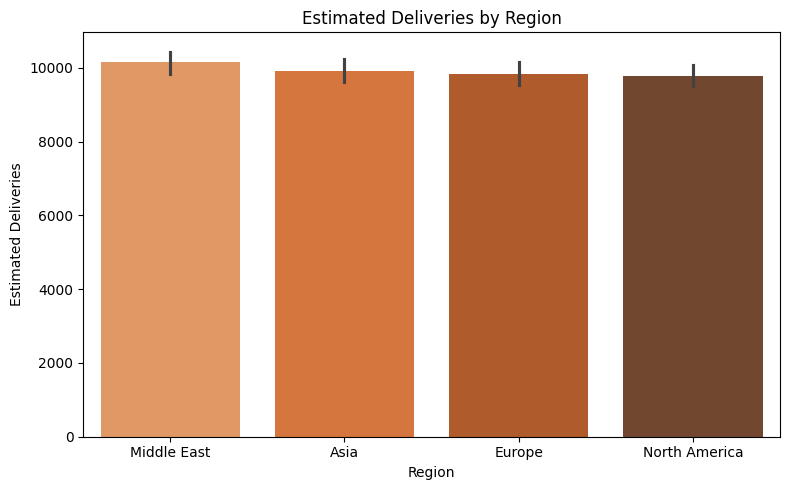

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Region', y='Estimated_Deliveries',
 hue='Region', palette='Oranges_d', legend=False)
plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

### 5.3 Average Deliveries Over Time

This line chart shows the trend of deliveries year by year. Is Tesla growing?

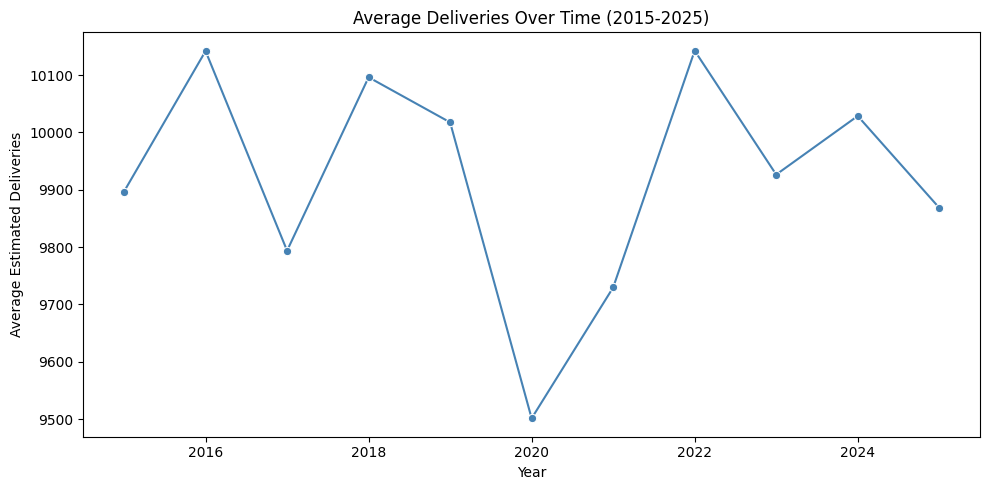

In [8]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend, x='Year', y='Estimated_Deliveries',
 marker='o', color='steelblue')
plt.title("Average Deliveries Over Time (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Average Estimated Deliveries")
plt.tight_layout()
plt.show()

### 5.4 Production Units vs Deliveries

This scatter plot shows the relationship between production and deliveries. We can already see from this that they move almost perfectly together which is a red flag for data leakage. A model shouldn't use production numbers to predict deliveries because in real life we don't know production before deliveries happen.

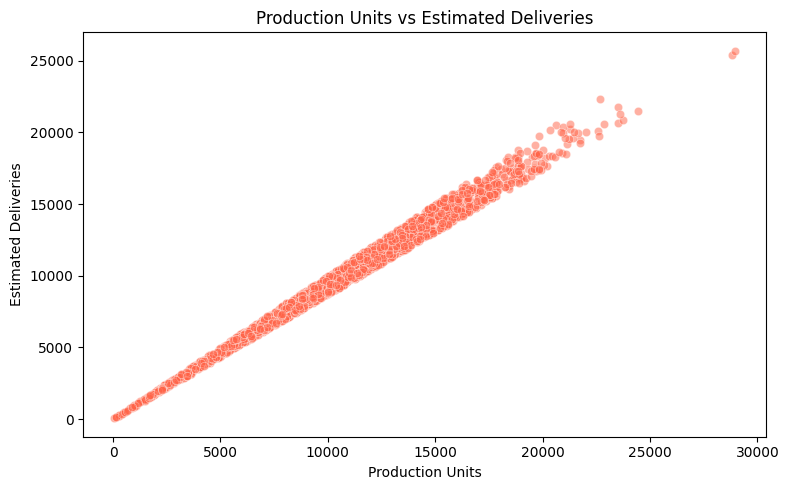

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Production_Units', y='Estimated_Deliveries',
 alpha=0.5, color='tomato')
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

### 5.5 Correlation Heatmap

The correlation heatmap shows how strongly each column is related to every other column. Numbers close to 1 or -1 mean strong relationship. We can clearly see Production_Units has 0.99 correlation with Estimated_Deliveries and CO2_Saved_tons has 0.83 both are data leakage and need to be dropped.

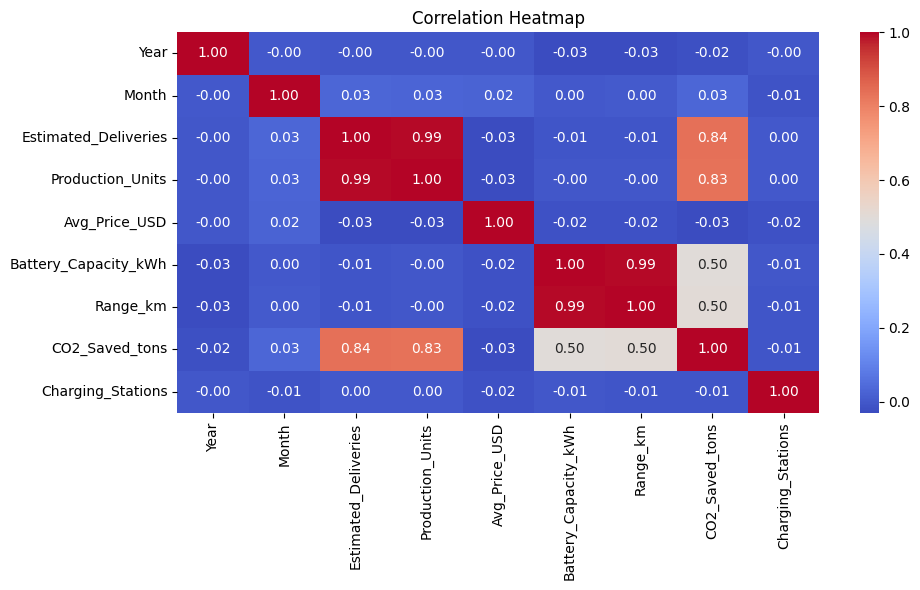


 Production_Units 0.99 correlation with target = DATA LEAKAGE
 CO2_Saved_tons 0.83 correlation with target = DATA LEAKAGE
 Both will be dropped in next step!


In [10]:
num_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("\n Production_Units 0.99 correlation with target = DATA LEAKAGE")
print(" CO2_Saved_tons 0.83 correlation with target = DATA LEAKAGE")
print(" Both will be dropped in next step!")

## Step 6 Dropping Unnecessary Columns

After looking at the heatmap we found 3 columns that either cause data leakage or are just metadata and don't actually help in prediction:
- **Production_Units** 0.99 correlation with target. we won't know next month's production before predicting deliveries. Keeping this is basically giving the model the answer 
- **CO2_Saved_tons** 0.83 correlation. Same issue, derived from deliveries.
- **Source_Type** just tells us where the data came from. Has nothing to do with prediction.

In [11]:
cols_to_drop = ['Source_Type', 'CO2_Saved_tons', 'Production_Units']
df = df.drop(columns=cols_to_drop)

print(f" Dropped: {cols_to_drop}")
print(f"\nRemaining columns: {df.columns.tolist()}")
print(f"New shape: {df.shape}")

 Dropped: ['Source_Type', 'CO2_Saved_tons', 'Production_Units']

Remaining columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']
New shape: (2640, 9)


## Step 7 Feature Engineering

This is where we create new columns from existing ones to help the model understand time patterns better.  dataset is time series data so the model needs to know what happened in the past to predict the future. Two new features are created:
- **Deliveries_Lag1** last row's delivery value. Basically telling the model "here is what happened last month, use it as a hint."
- **Rolling_Mean_3** average of last 3 months. This smooths out sudden spikes and shows the real underlying trend instead of random noise.

In [12]:
# Lag Features - previous delivery values per Region and Model group
df['Lag1']  = df.groupby(['Region','Model'])['Estimated_Deliveries'].shift(1)
df['Lag2']  = df.groupby(['Region','Model'])['Estimated_Deliveries'].shift(2)
df['Roll3'] = df.groupby(['Region','Model'])['Estimated_Deliveries'].transform(lambda x: x.rolling(3).mean())

df['Lag1']  = df['Lag1'].fillna(df['Estimated_Deliveries'].mean())
df['Lag2']  = df['Lag2'].fillna(df['Estimated_Deliveries'].mean())
df['Roll3'] = df['Roll3'].fillna(df['Estimated_Deliveries'].mean())

df['Quarter'] = df['Month'].apply(lambda x: 1 if x<=3 else 2 if x<=6 else 3 if x<=9 else 4)
df['Is_Q4']   = (df['Quarter'] == 4).astype(int)

print('Feature Engineering done!')
print('New features: Lag1, Lag2, Roll3, Quarter, Is_Q4')
display(df[['Estimated_Deliveries','Lag1','Lag2','Roll3','Quarter','Is_Q4']].head(6))

Feature Engineering done!
New features: Lag1, Lag2, Roll3, Quarter, Is_Q4


,Estimated_Deliveries,Lag1,Lag2,Roll3,Quarter,Is_Q4
0,10348,9922.199621,9922.199621,9922.199621,1,0
1,12446,9922.199621,9922.199621,9922.199621,1,0
2,10835,9922.199621,9922.199621,9922.199621,1,0
3,8122,9922.199621,9922.199621,9922.199621,1,0
4,13902,9922.199621,9922.199621,9922.199621,1,0
5,7597,9922.199621,9922.199621,9922.199621,1,0


## Step 8 Defining X and y

Here we separate our data into features (X) and target (y). 

In [13]:
y = df['Estimated_Deliveries']
X = df.drop(columns=['Estimated_Deliveries'])

print(" Target (y): Estimated_Deliveries")
print(f" Shape: {y.shape}")
print("\n Features (X) with index positions:")
for i, col in enumerate(X.columns):
 print(f" [{i}] {col}")
print(f"\nX shape: {X.shape}")

 Target (y): Estimated_Deliveries
 Shape: (2640,)

 Features (X) with index positions:
 [0] Year
 [1] Month
 [2] Region
 [3] Model
 [4] Avg_Price_USD
 [5] Battery_Capacity_kWh
 [6] Range_km
 [7] Charging_Stations
 [8] Lag1
 [9] Lag2
 [10] Roll3
 [11] Quarter
 [12] Is_Q4

X shape: (2640, 13)


## Step 9 Train Test Split

Since this is time series data we cannot do a random split that would mix up past and future data which doesn't make sense. Instead we use index slicing to keep the time order intact. First 80% of rows (older data) go to training and last 20% (recent data) go to testing. 

In [14]:
split_idx = int(0.8 * len(df))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f" Train : {X_train.shape} {X_train['Year'].min()} to {X_train['Year'].max()}")
print(f" Test : {X_test.shape} {X_test['Year'].min()} to {X_test['Year'].max()}")
print(f"\n 80% train {len(X_train)} rows")
print(f" 20% test {len(X_test)} rows")

 Train : (2112, 13) 2015 to 2023
 Test : (528, 13) 2023 to 2025

 80% train 2112 rows
 20% test 528 rows


## Step 10 Building the sklearn Pipeline

This is the most important step. Instead of doing preprocessing manually for train and test separately (which causes data leakage), we use sklearn's Pipeline which chains all steps together into one single object. The pipeline has 4 stages:
- **Stage 1 (OHE)** converts Region and Model text columns to numbers using OneHotEncoding. We use integer index positions [2,3] not column names because the transformer works with NumPy arrays internally, so column names are no longer available at that stage. remainder=passthrough keeps all other columns.
- **Stage 2 (Scaling)** MinMaxScaler converts all 20 columns (after OHE) to range 0-1 so no column dominates just because its numbers are bigger.
- **Stage 3 (Feature Selection)** SelectKBest picks top 15 most useful features based on their correlation with the target.
- **Stage 4 (Model)** Random Forest trains on the final selected features.

In [15]:
# Stage 1 One Hot Encoding
# Region is at index [2], Model is at index [3]

trf1 = ColumnTransformer([
 ('ohe', OneHotEncoder(sparse_output=False,
 handle_unknown='ignore'), [2, 3])
], remainder='passthrough')

# Stage 2 Feature Scaling
# After OHE: Region(4) + Model(5) + 11 numeric = 20 total cols
trf2 = ColumnTransformer([
 ('scale', MinMaxScaler(), slice(0, 20))
])

# Stage 3 Feature Selection
# Keep top 15 features most correlated with target
trf3 = SelectKBest(score_func=f_regression, k=15)

# Stage 4 Model
trf4 = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

# Chain all into Pipeline
pipe = Pipeline([
 ('ohe_encoding', trf1),
 ('scaling', trf2),
 ('feature_selection', trf3),
 ('model', trf4)
])

print(" Pipeline built!")
print("\nStages:")
print(" Stage 1 OneHotEncoder (Region, Model)")
print(" Stage 2 MinMaxScaler (all 20 cols)")
print(" Stage 3 SelectKBest (top 15 features)")
print(" Stage 4 RandomForest (final model)")

 Pipeline built!

Stages:
 Stage 1 OneHotEncoder (Region, Model)
 Stage 2 MinMaxScaler (all 20 cols)
 Stage 3 SelectKBest (top 15 features)
 Stage 4 RandomForest (final model)


## Step 11 Fitting the Pipeline

One single .fit() call runs all 4 stages automatically on training data. The OHE learns categories, scaler learns min/max values, SelectKBest scores features and Random Forest trains all in one shot. 

In [16]:
pipe.fit(X_train, y_train)
print(" Pipeline fitted on training data!")

print("\n OHE categories learned:")
cats = pipe.named_steps['ohe_encoding'].named_transformers_['ohe'].categories_
print(f" Region {cats[0]}")
print(f" Model {cats[1]}")

 Pipeline fitted on training data!

 OHE categories learned:
 Region ['Asia' 'Europe' 'Middle East' 'North America']
 Model ['Cybertruck' 'Model 3' 'Model S' 'Model X' 'Model Y']


## Step 12 Visualizing the Pipeline

In [17]:
from sklearn import set_config
set_config(display='diagram')
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ohe_encoding', ...), ('scaling', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Step 13 Predictions and Evaluation

Now we use the trained pipeline to predict on test data and evaluate how good the model is. We are checking 3 metrics MAE tells us average error in number of cars, RMSE punishes big mistakes more heavily, and R tells us how much of the delivery pattern the model actually learned. We also compare Random Forest against Linear Regression as a baseline.

In [18]:
# Random Forest predictions
y_pred_rf = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print(" Random Forest Pipeline Results:")
print(f" MAE (Mean Absolute Error) : {mae:,.2f}")
print(f" RMSE (Root Mean Sq Error) : {rmse:,.2f}")
print(f" R (R-squared Score) : {r2:.4f}")

# Linear Regression as baseline
lr_pipe = Pipeline([
 ('ohe_encoding', trf1),
 ('scaling', trf2),
 ('feature_selection', trf3),
 ('model', LinearRegression())
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print("\n Linear Regression Pipeline Results:")
print(f" MAE : {mean_absolute_error(y_test, y_pred_lr):,.2f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.2f}")
print(f" R : {r2_score(y_test, y_pred_lr):.4f}")

 Random Forest Pipeline Results:
 MAE (Mean Absolute Error) : 1,375.81
 RMSE (Root Mean Sq Error) : 1,754.16
 R (R-squared Score) : 0.7713

 Linear Regression Pipeline Results:
 MAE : 68.30
 RMSE : 84.95
 R : 0.9995


## Step 14 Actual vs Predicted Plot

This scatter plot visually shows how close our predictions are to the actual values. If the model was perfect, all points would sit exactly on the red dotted diagonal line. The closer the points are to that line, the better the model is performing.

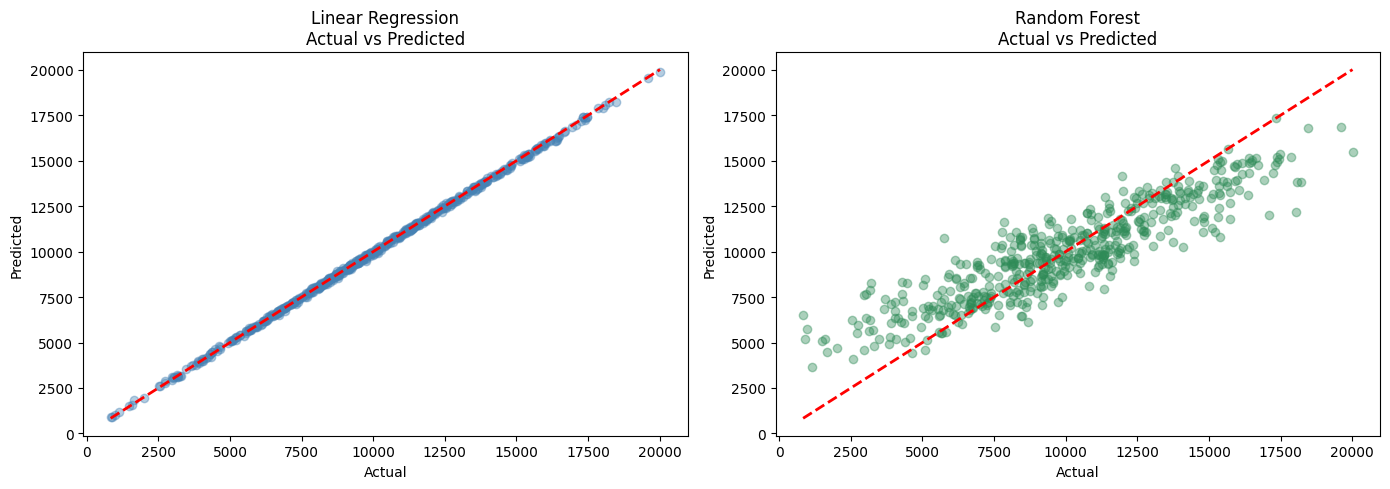

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
 [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title("Linear Regression\nActual vs Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

axes[1].scatter(y_test, y_pred_rf, alpha=0.4, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()],
 [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_title("Random Forest\nActual vs Predicted")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

## Step 15 Hyperparameter Tuning (GridSearchCV)

When we built the Random Forest we just guessed the settings n_estimators=200, max_depth=5. We don't actually know if those are the best. GridSearchCV systematically evaluates every specified hyperparameter combination using cross-validation and selects the combination that achieves the highest average validation score.

In [20]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10],
    'feature_selection__k': [ 15]
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='r2', verbose=1)
grid.fit(X_train, y_train)

print(f"\n Best Parameters : {grid.best_params_}")
print(f" Best CV R Score : {grid.best_score_:.4f}")

best_pred = grid.predict(X_test)
print(f"\n Tuned Model Results:")
print(f" MAE : {mean_absolute_error(y_test, best_pred):,.2f}")
print(f" RMSE : {np.sqrt(mean_squared_error(y_test, best_pred)):,.2f}")
print(f" R : {r2_score(y_test, best_pred):.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits

 Best Parameters : {'feature_selection__k': 15, 'model__max_depth': 10, 'model__n_estimators': 200}
 Best CV R Score : 0.7233

 Tuned Model Results:
 MAE : 621.62
 RMSE : 824.79
 R : 0.9494


## Step 16 Time Series Forecasting (ARIMA)

The Random Forest above predicts deliveries based on features like Region, Model, Price etc. But ARIMA is a pure time series model it only looks at past delivery values to predict future ones. Aggregate data to yearly averages, fit ARIMA with order (1,1,1) meaning look back 1 year, difference once to make data stable, and learn from 1 past error. Then we forecast the next 3 years.

In [21]:
# Aggregate to yearly average
yearly_ts = df.groupby('Year')['Estimated_Deliveries'].mean()

# Convert to datetime index so ARIMA understands it as time data
yearly_ts.index = pd.date_range(
 start='2015', periods=len(yearly_ts), freq='YE')

print(" Yearly Average Deliveries:")
print(yearly_ts)

# Fit ARIMA (p=1, d=1, q=1)
arima_model = ARIMA(yearly_ts, order=(1, 1, 1))
arima_result = arima_model.fit()

print("\n ARIMA model fitted!")


# Forecast next 3 years
forecast_steps = 3
forecast = arima_result.forecast(steps=forecast_steps)
forecast_years = pd.date_range(
 start=yearly_ts.index[-1],
 periods=forecast_steps + 1,
 freq='YE')[1:]

print(f"\n Forecast for next {forecast_steps} years:")
for yr, val in zip(forecast_years, forecast):
 print(f" {yr.year} {val:,.0f} avg deliveries")

 Yearly Average Deliveries:
2015-12-31     9896.945833
2016-12-31    10142.004167
2017-12-31     9793.820833
2018-12-31    10096.266667
2019-12-31    10017.625000
2020-12-31     9501.400000
2021-12-31     9729.650000
2022-12-31    10142.583333
2023-12-31     9926.562500
2024-12-31    10028.745833
2025-12-31     9868.591667
Freq: YE-DEC, Name: Estimated_Deliveries, dtype: float64

 ARIMA model fitted!

 Forecast for next 3 years:
 2026 9,881 avg deliveries
 2027 9,884 avg deliveries
 2028 9,884 avg deliveries


## Step 17 ARIMA Forecast Plot

This plot shows the historical delivery trend from 2015 to 2025 in blue and the ARIMA forecast for 2026, 2027 and 2028 in red dotted line. Where the blue line ends is present day and the red shows what we expect based on the learned pattern.

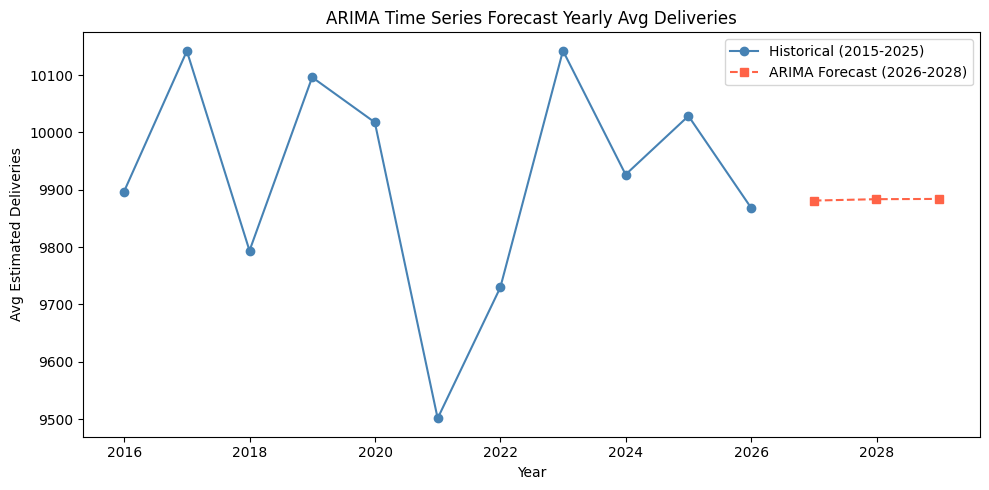

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(yearly_ts.index, yearly_ts.values,
 marker='o', label='Historical (2015-2025)', color='steelblue')

plt.plot(forecast_years, forecast.values,
 marker='s', linestyle='--',
 label='ARIMA Forecast (2026-2028)', color='tomato')

plt.title("ARIMA Time Series Forecast Yearly Avg Deliveries")
plt.xlabel("Year")
plt.ylabel("Avg Estimated Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

## Step 18 Forecast Table

A clean table showing the ARIMA forecast values for the next 3 years. This makes it easy to read the predicted numbers directly without having to read off a graph.

In [23]:
forecast_df = pd.DataFrame({
 'Year': [yr.year for yr in forecast_years],
 'Forecast Deliveries': [f"{round(val):,}" for val in forecast]
})

print(" ARIMA Forecast Table:")
display(forecast_df)

 ARIMA Forecast Table:


,Year,Forecast Deliveries
0,2026,"9,881"
1,2027,"9,884"
2,2028,"9,884"


## Step 19 Saving the Pipeline

Finally we save the entire trained pipeline as a single .pkl file using pickle. This means next time we don't need to retrain everything from scratch just load the file and predict directly on raw data. In production this is how ML models are deployed train once, save, load anywhere.

In [24]:
pickle.dump(pipe, open('tesla_pipeline.pkl', 'wb'))
print(" Pipeline saved as tesla_pipeline.pkl")

# Verify it loads correctly
loaded_pipe = pickle.load(open('tesla_pipeline.pkl', 'rb'))
verify_pred = loaded_pipe.predict(X_test)
print(f" Loaded pipeline works! Sample predictions: {verify_pred[:3].round(0)}")

 Pipeline saved as tesla_pipeline.pkl
 Loaded pipeline works! Sample predictions: [ 9616. 10385. 13153.]
